In [9]:
import sys

print(sys.executable)

C:\Proyectos\Laboratorios\Inteligencia Artificial\Lab_01\venv_ia1\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
matricula = pd.read_csv("matricula_sistemas.csv")
matricula.describe()

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


In [3]:
col = matricula["num_matriculados"]
print("Media:", col.mean())
print("Mediana:", col.median())
print("Moda:", col.mode().tolist())
print("Rango:", col.max() - col.min())
print("Varianza:", col.var())
print("Desviacion estandar:", col.std())

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviacion estandar: 34.12243513745971


In [4]:
matricula.corr(numeric_only=True)["num_matriculados"]

num_postulantes            0.951145
becas_otorgadas            0.895512
tasa_desercion_anterior   -0.436143
campania_difusion          0.496448
num_matriculados           1.000000
Name: num_matriculados, dtype: float64

In [6]:
postulantes = matricula["num_postulantes"]
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std()
matriculados = matricula["num_matriculados"].astype(float)

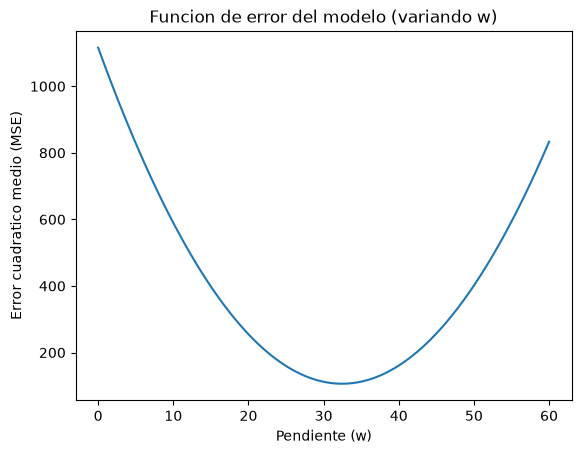

In [10]:
b_fijo = 137.1
valores_w = np.linspace(0, 60, 100)
errores = []
for w in valores_w:
    prediccion = w * postulantes_norm + b_fijo
    mse = np.mean((prediccion - matriculados) ** 2)
    errores.append(mse)
plt.plot(valores_w, errores)
plt.xlabel("Pendiente (w)")
plt.ylabel("Error cuadratico medio (MSE)")
plt.title("Funcion de error del modelo (variando w)")
plt.show()

In [11]:
w, b = 0.0, 0.0
tasa_aprendizaje = 0.3
n = len(postulantes_norm)

for paso in range(1, 11):
    prediccion = w * postulantes_norm + b
    error = prediccion - matriculados
    mse = np.mean(error ** 2)
    gradiente_w = (2 / n) * np.sum(error * postulantes_norm)
    gradiente_b = (2 / n) * np.sum(error)
    
    # Actualización de parámetros usando el gradiente actual
    w = w - (tasa_aprendizaje * gradiente_w)
    b = b - (tasa_aprendizaje * gradiente_b)
    
    print(f"Paso {paso}: MSE={mse:.2f} w={w:.4f} b={b:.4f}")

Paso 1: MSE=19907.67 w=18.6618 b=82.2500
Paso 2: MSE=3295.39 w=26.5931 b=115.1500
Paso 3: MSE=620.37 w=29.9639 b=128.3100
Paso 4: MSE=189.29 w=31.3965 b=133.5740
Paso 5: MSE=119.76 w=32.0053 b=135.6796
Paso 6: MSE=108.53 w=32.2641 b=136.5218
Paso 7: MSE=106.72 w=32.3741 b=136.8587
Paso 8: MSE=106.42 w=32.4208 b=136.9935
Paso 9: MSE=106.37 w=32.4407 b=137.0474
Paso 10: MSE=106.37 w=32.4491 b=137.0690


In [12]:
X_simple = postulantes_norm.values.reshape(-1, 1)
comprobacion = LinearRegression().fit(X_simple, matriculados)
w_sk = round(comprobacion.coef_[0], 2)
b_sk = round(comprobacion.intercept_, 2)
print("Scikit-learn: w =", w_sk, " b =", b_sk)

Scikit-learn: w = 32.46  b = 137.08


In [14]:
columnas = ["num_postulantes", "becas_otorgadas",
"tasa_desercion_anterior", "campania_difusion"]

X = matricula[columnas]
y = matricula["num_matriculados"]
modelo = LinearRegression()
modelo.fit(X, y)
print("Coeficientes:", dict(zip(X.columns, modelo.coef_.round(2))))
print("Intercepto:", round(modelo.intercept_, 2))
print("R2 sobre los datos de entrenamiento:", round(modelo.score(X, y), 3))

Coeficientes: {'num_postulantes': np.float64(0.49), 'becas_otorgadas': np.float64(1.38), 'tasa_desercion_anterior': np.float64(-328.52), 'campania_difusion': np.float64(6.67)}
Intercepto: 37.84
R2 sobre los datos de entrenamiento: 0.953


In [15]:
semestre_nuevo = pd.DataFrame([{
"num_postulantes": 300,
"becas_otorgadas": 30,
"tasa_desercion_anterior": 0.09,
"campania_difusion": 1,
}])
prediccion = modelo.predict(semestre_nuevo)
print("Matricula estimada 2027-I:", round(prediccion[0], 0), "estudiantes")

Matricula estimada 2027-I: 204.0 estudiantes


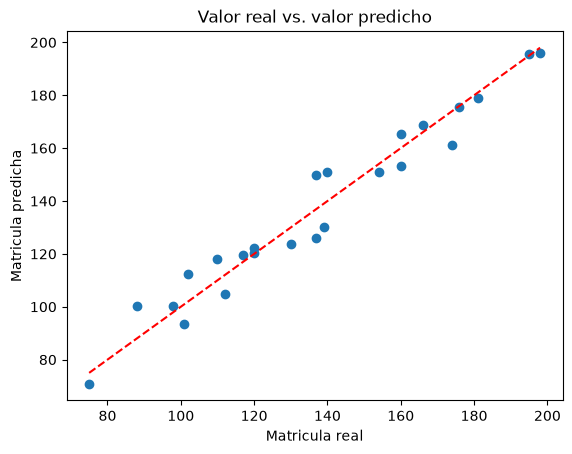

In [16]:
predicciones = modelo.predict(X)
plt.scatter(y, predicciones)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Matricula real")
plt.ylabel("Matricula predicha")
plt.title("Valor real vs. valor predicho")
plt.show()